### Install all dependencies

In [415]:
from datetime import datetime

from polars import DataFrame
import polars as pl
import numpy as np

from Domain import (DataColumn, DataRequest, DateTimeLevel,
                    LinearRegressionParam, ModelAlgorithm, ModelConfig,
                    ModelPredictParams, ModelRequest, ModelType)
from ExternalServices import ExternalServiceFacade
from services.AbstractServices import AbstractExternalService
from services.PipelineFactories import (DataPipelineFactory,
                                        InferencePipelineFactory,
                                        ModelPipelineFactory)

### Domain models

In [416]:
# Data request
data_columns1 = DataColumn(ColumnName="sensor_a_1_temperature_°C", DataType="float")
data_columns2 = DataColumn(ColumnName="sensor_a_2_humidity_%", DataType="float")
data_columns3 = DataColumn(ColumnName="sensor_a_3_pressure_hPa", DataType="float")

linear_regression_params = LinearRegressionParam(Id=1, 
                                          TypeOfAlgorithm=ModelAlgorithm.LINEAR_REGRESSION, 
                                          NJobs=1)
model_config = ModelConfig(
    ModelConfigGuid="DF-1234-5678-ABCD-9876543210",
    ParentWorkspaceGuid="DF-1234-5678-ABCD-9876543210",
    ModelName="TestModel",
    DataSplitRatio=0.8,
    ForecastingDate=datetime(2026, 7, 9, 12, 0, 0),
    DateTimeLevel=DateTimeLevel.STANDARD,
    ModelType=ModelType.FORECASTING,
    ModelAlgorithm=ModelAlgorithm.LINEAR_REGRESSION,
    Features=[data_columns1, data_columns2, data_columns3],
    Targets=[data_columns1, data_columns2],
    ModelParameter=linear_regression_params
)
data_request = DataRequest(
    WorkspaceId="DF-1234-5678-ABCD-9876543210",
    Token="token",
    DataSource="InMemory",
    StartDateUnix=1700000000,
    EndDateUnix=1700003600,
    Project="Fictiebrug",
    Points=200,
    Timelevel=13,
    TimelevelRange=964000000000.0,
    ObservationIds=[1, 2, 3, 4, 5],
    ValueTypeIds=[1, 2, 3],
    ProvideData=False
)
# From January 1th 2024 12:00 till 2024 January 2nd 12:00
model_predict_params = ModelPredictParams(
    current_date=datetime(2026, 6, 9, 12, 0, 0), 
    end_date=datetime(2026, 8, 9, 12, 0, 0))

model_request = ModelRequest(
    DataRequest=data_request, 
    ModelConfig=model_config, 
    Operations=[],
    Model_Location="InMemory", 
    PredictionParameters=model_predict_params)

### Setup dummy data

In [417]:

# 1. Setup parameters
start_date = "2026-01-09 12:00:00"
end_date = "2026-07-09 12:00:00"

# 2. Create the baseline schema for our 3 sensors
sensors_df = pl.DataFrame({
    "sensor": ["sensor_a_1", "sensor_a_2", "sensor_a_3"],
    "valuetype": ["temperature", "humidity", "pressure"],
    "unit": ["°C", "%", "hPa"],
    "base_value": [24.0, 47.0, 1014.0],
    "noise_scale": [0.1, 0.2, 0.05] # Standard deviation for random walk
})

# 3. Generate a continuous date range from start_date to end_date with 5-minute intervals
timeline_df = pl.select(
    pl.datetime_range(
        start=pl.lit(start_date).str.to_datetime(),
        end=pl.lit(end_date).str.to_datetime(),
        interval="24h",
        eager=True,
        time_zone="UTC"
    ).alias("timestamp"))

# 4. Cross join to interleave sensors for every timestamp
df = timeline_df.join(sensors_df, how="cross")

In [418]:
# 5. Simulate data using random walks per sensor group
# We use a cumulative sum of normal distributions to simulate real sensor drift
np.random.seed(42) # For reproducibility
total_rows = len(df)
random_noise = np.random.normal(0, 1, total_rows)

df = (
    df.with_columns(pl.lit(random_noise).alias("raw_noise"))
    .sort(["sensor", "timestamp"])
    .with_columns(
        # Cumulative sum of noise * scale added to the base value
        (pl.col("base_value") + (pl.col("raw_noise") * pl.col("noise_scale")).cum_sum().over("sensor"))
        .round(2)
        .alias("value")
    )
    # Final cleanup to match your exact column order
    .select(["timestamp", "value", "sensor", "valuetype", "unit"])
    .sort(["timestamp", "sensor"])
)
print(df.head(9))
print(df.tail(3))

shape: (9, 5)
┌─────────────────────────┬─────────┬────────────┬─────────────┬──────┐
│ timestamp               ┆ value   ┆ sensor     ┆ valuetype   ┆ unit │
│ ---                     ┆ ---     ┆ ---        ┆ ---         ┆ ---  │
│ datetime[μs, UTC]       ┆ f64     ┆ str        ┆ str         ┆ str  │
╞═════════════════════════╪═════════╪════════════╪═════════════╪══════╡
│ 2026-01-09 12:00:00 UTC ┆ 24.05   ┆ sensor_a_1 ┆ temperature ┆ °C   │
│ 2026-01-09 12:00:00 UTC ┆ 46.97   ┆ sensor_a_2 ┆ humidity    ┆ %    │
│ 2026-01-09 12:00:00 UTC ┆ 1014.03 ┆ sensor_a_3 ┆ pressure    ┆ hPa  │
│ 2026-01-10 12:00:00 UTC ┆ 24.2    ┆ sensor_a_1 ┆ temperature ┆ °C   │
│ 2026-01-10 12:00:00 UTC ┆ 46.93   ┆ sensor_a_2 ┆ humidity    ┆ %    │
│ 2026-01-10 12:00:00 UTC ┆ 1014.02 ┆ sensor_a_3 ┆ pressure    ┆ hPa  │
│ 2026-01-11 12:00:00 UTC ┆ 24.36   ┆ sensor_a_1 ┆ temperature ┆ °C   │
│ 2026-01-11 12:00:00 UTC ┆ 47.08   ┆ sensor_a_2 ┆ humidity    ┆ %    │
│ 2026-01-11 12:00:00 UTC ┆ 1014.0  ┆ sensor_a_3 ┆

### Setup dummy data source

In [419]:
# Demonstration data source, since the original software was developed with Sweco internal tool.
class InMemoryExternalService(AbstractExternalService):
    def __init__(self):
        super().__init__()
        self.data = df

    async def return_value(self, request) -> DataFrame:
        return self.data

### Setup all the demo services

In [420]:
external_service = InMemoryExternalService()
facade = ExternalServiceFacade(external_service)
data_pipeline_factory = DataPipelineFactory(facade)
model_pipeline_factory = ModelPipelineFactory(data_pipeline_factory)
inference_pipeline_factory = InferencePipelineFactory(data_pipeline_factory)

In [421]:
model_pipeline = model_pipeline_factory.create_forecasting_pipeline()

In [422]:
result = await model_pipeline.execute(model_request)

In [423]:
inference_pipeline = inference_pipeline_factory.create_forecast_inference_pipeline(result.model_pipeline)

In [424]:
end_result = await inference_pipeline.execute(model_request)

In [425]:
end_result.data.head()

timestamp,sensor_a_1_temperature_°C,sensor_a_2_humidity_%,sensor_a_3_pressure_hPa
"datetime[μs, UTC]",f64,f64,f64
2026-01-09 12:00:00 UTC,24.05,46.97,1014.03
2026-01-10 12:00:00 UTC,24.2,46.93,1014.02
2026-01-11 12:00:00 UTC,24.36,47.08,1014.0
2026-01-12 12:00:00 UTC,24.41,46.99,1013.97
2026-01-13 12:00:00 UTC,24.44,46.6,1013.89


### Show the forecasts

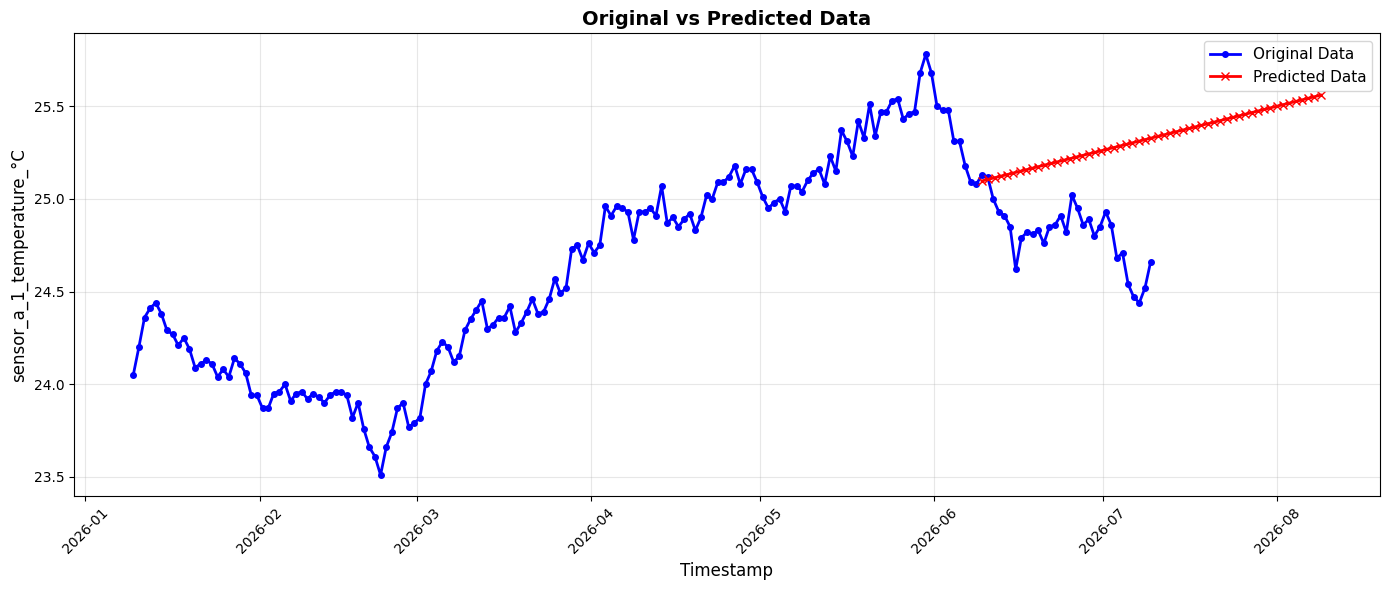

In [426]:
import matplotlib.pyplot as plt

original_df = end_result.get_original_data(["sensor_a_1_temperature_°C", "sensor_a_2_humidity_%", "sensor_a_3_pressure_hPa"])
forecasted_df = end_result.get_predicted_data()

target_col = original_df.columns[1]

x_orig = original_df["timestamp"].to_list()
y_orig = original_df[target_col].to_list()

x_pred = forecasted_df["timestamp"].to_list()
y_pred = forecasted_df[target_col].to_list()

plt.figure(figsize=(14, 6))
plt.plot(x_orig, y_orig, label="Original Data", color="blue", marker="o", linewidth=2, markersize=4)
plt.plot(x_pred, y_pred, label="Predicted Data", color="red", marker="x", linewidth=2, markersize=6)

plt.xlabel("Timestamp", fontsize=12)
plt.ylabel(target_col, fontsize=12)
plt.title("Original vs Predicted Data", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()